# Above Ground Biomass Estimation from Drone Imagery using Deep Learning

**A step-by-step tutorial using the ReforesTree dataset, ResNet-18, RoI Align, and PyTorch Lightning**

---

## Motivation: Why does Above Ground Biomass matter?

**Above Ground Biomass (AGB)** is the total mass of living organic material in the above-ground portion of a plant — trunks, branches, and leaves. It is one of the most critical indicators in ecological science because:

- **Carbon accounting**: Forests store ~80% of all terrestrial above-ground carbon. Accurate AGB maps are essential for REDD+ programmes and national climate commitments.
- **Forest monitoring**: Tracking AGB changes over time reveals deforestation, degradation, or restoration progress at landscape scale.
- **Agroforestry assessment**: In multi-species food systems like the sites studied here, tree biomass helps quantify productivity and ecosystem services.

Traditionally, AGB is measured through **field campaigns**: ecologists walk each plot, measure trunk diameter at breast height (DBH) and height for every tree, and apply species-specific **allometric equations** (dendrology-based formulas) to compute biomass in kg or Mg. This process is accurate but expensive, slow, and limited in spatial coverage.

---

## Why Drone Imagery?

Unmanned Aerial Vehicles (UAVs) can survey hundreds of hectares in a single flight at **2 cm/pixel resolution**, capturing individual tree crowns in fine detail. This opens the door to:

- Mapping AGB at scale without exhaustive field campaigns
- Detecting individual trees with object detection models
- Linking visual crown features — color, texture, shape, shadow — to field-measured biomass

---

## This Tutorial

In this notebook we demonstrate a full **deep learning regression pipeline** that estimates above ground biomass from high-resolution drone imagery. Steps covered:

1. Load a custom `NonGeoDataset` wrapping ReforesTree drone tiles and field-measured AGB labels
2. Visualize annotated tree crowns on 4000×4000 pixel orthomosaic tiles
3. Understand **visual embeddings**: what ResNet-18 feature maps represent
4. Build a **Sparse Feature Regression** model:
   - A frozen **ResNet-18** backbone extracts per-patch feature maps via a moving 1000×1000 window
   - **RoI Align** "snips" a 7×7 feature grid for each labeled tree bounding box
   - An **MLP regression head** maps visual features → individual AGB predictions
   - A **global aggregation loss** trains on tile-level biomass sums, robust to per-tree label noise
5. Train with PyTorch Lightning and track metrics with Weights & Biases
6. Evaluate and visualize per-tree biomass predictions against ground truth

> **Dataset**: ReforesTree — publicly available on [Zenodo](https://zenodo.org/records/6813783).  
> **Citation**: *Reiersen et al., 2022 — [arxiv.org/abs/2201.11192](https://arxiv.org/abs/2201.11192)*

## Prerequisites & How to Run

**Where to run**: This notebook is designed to run on **Kaggle** (GPU T4 or P100, free tier) or **Google Colab** (T4 GPU, free tier). It will not run on a CPU in reasonable time due to the 4000×4000 pixel image processing.

**Dataset**: Add the ReforesTree dataset to your Kaggle notebook via:  
`+ Add Data → Search "reforestree-dataset"` → the root path will be `/kaggle/input/reforestree-dataset/`

**WandB (optional)**: Add your WandB API key to Kaggle Secrets under the name `wandb`. If you skip this, remove or comment out the WandB logger cells and pass `logger=False` to the `Trainer`.

**Python dependencies**:

```
torch >= 2.0
torchvision >= 0.15
torchgeo >= 0.5
pytorch-lightning >= 2.0
timm >= 0.9
wandb
```

**Repository**: Source code and architecture diagram are hosted at [github.com/emanuel-gf/ReforesTree](https://github.com/emanuel-gf/ReforesTree) (branch: `first`).

In [ ]:
## Check if the dataset is properly saved.
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

## 1. Environment Setup

We need three libraries beyond the standard scientific Python stack:

| Library | Purpose |
|---|---|
| `torchgeo` | Geospatial dataset classes for remote sensing data. Provides `NonGeoDataset`, the base class we extend for ReforesTree. |
| `pytorch-lightning` | High-level training framework handling the training loop, checkpointing, and mixed precision. Keeps boilerplate out of science code. |
| `timm` | PyTorch Image Models — a large collection of pretrained vision backbones. Used here to load ResNet-18 weights pretrained on ImageNet-1k (`resnet18.a1_in1k`). |
| `wandb` | Weights & Biases — experiment tracking. Logs loss curves, model checkpoints, and hyperparameters to a cloud dashboard. |

> **Note**: On **Kaggle**, these cells execute as-is. On **Google Colab**, prefix with `!` (e.g. `!pip install -U torchgeo`).

In [ ]:
pip install -U torchgeo

In [ ]:
pip install pytorch-lightning

## 2. Imports

Imports are organized into four groups:

- **Standard library + data tools**: `os`, `pathlib`, `numpy`, `pandas`, `PIL`, `matplotlib` — file I/O, array math, and visualization.
- **TorchGeo**: `NonGeoDataset` and its utilities. `NonGeoDataset` is the right base class when images are stored as plain files without embedded CRS or geotransform metadata (which is the case for our PNG tiles).
- **PyTorch core**: `torch`, `nn`, `roi_align`, `DataLoader`. The `roi_align` function from `torchvision.ops` is a critical building block — it extracts fixed-size feature crops aligned to arbitrary bounding boxes with bilinear interpolation.
- **timm**: Pretrained backbone factory. `timm.create_model` lets us load any architecture with pretrained weights in one line.
- **Lightning + callbacks**: `LightningModule`, `Trainer`, `ModelCheckpoint`, `EarlyStopping`, and `WandbLogger` — the training orchestration layer.

In [46]:
import glob
import os
from collections.abc import Callable
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.figure import Figure
from PIL import Image
from typing import Optional, Dict
from pathlib import Path
from typing import Optional, Callable

from torchgeo.datasets import NonGeoDataset
from torchgeo.datasets.errors import DatasetNotFoundError
from torchgeo.datasets.utils import check_integrity, download_and_extract_archive, extract_archive

import torch
import torch.nn as nn
from torchvision.ops import roi_align
from torch import Tensor
from torch.utils.data import DataLoader, random_split, Subset

import timm


from lightning.pytorch import LightningModule, Trainer, seed_everything, Callback
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import WandbLogger

## 3. Custom Dataset Class — `AGB_Reforest`

TorchGeo ships with a built-in `ReforesTree` dataset class, but we subclass `NonGeoDataset` directly to add behaviour needed for this regression task.

Key additions over the base class:

| Addition | Why |
|---|---|
| **Z-score normalized AGB** in `_load_target` | Raw AGB is heavily right-skewed (small cacao trees vs. large timber trees). Normalizing stabilizes gradients and prevents the loss from being dominated by outlier high-AGB tiles. |
| **`agb_total` field** | Provides the tile-level AGB sum as a fallback target. |
| **`name2idx` mapping** | The dataset has both coarse `group` labels (6 classes: banana, cacao, citrus, fruit, timber, other) and fine-grained `name` labels (individual species). Both are indexed for flexible visualization and potential multi-task learning. |
| **Bad-path filter** in `_load_files` | Five specific tiles have a [known GPS mismatch](https://github.com/gyrrei/ReforesTree/issues/6) — their bounding boxes do not align to the correct image region. These are excluded before any processing. |

The dataset class wraps both the image tiles and the annotation CSV (`mapping/final_dataset.csv`). The CSV contains one row per annotated tree with columns for bounding box coordinates, species name, group class, and computed AGB.

Each call to `dataset[i]` returns a dictionary:

```python
{
  'image':      Tensor[3, 4000, 4000],  # float32, pixel values 0–255
  'bbox_xyxy':  Tensor[N, 4],           # bounding boxes in pixel coords [x1, y1, x2, y2]
  'label':      Tensor[N],              # group class index (0–5)
  'label_name': Tensor[N],              # species class index
  'agb':        Tensor[N],              # z-score normalized AGB per tree
  'agb_total':  Tensor[1],              # raw AGB sum for the whole tile (kg)
}
```

where `N` is the number of labeled trees in that tile (varies from tile to tile).

In [47]:
## Create the class, modifying it from torchgeo.

class AGB_Reforest(NonGeoDataset):
    """ReforesTree dataset.

    The `ReforesTree <https://github.com/gyrrei/ReforesTree>`__
    dataset contains drone imagery that can be used for tree crown detection,
    tree species classification and Aboveground Biomass (AGB) estimation.

    Dataset features:

    * 100 high resolution RGB drone images at 2 cm/pixel of size 4,000 x 4,000 px
    * more than 4,600 tree crown box annotations
    * tree crown matched with field measurements of diameter at breast height (DBH),
      and computed AGB and carbon values

    Dataset format:

    * images are three-channel pngs
    * annotations are csv file

    Dataset Classes:

    0. other
    1. banana
    2. cacao
    3. citrus
    4. fruit
    5. timber

    If you use this dataset in your research, please cite the following paper:

    * https://arxiv.org/abs/2201.11192

    .. versionadded:: 0.3
    """

    classes = ('other', 'banana', 'cacao', 'citrus', 'fruit', 'timber')
    url = 'https://zenodo.org/records/6813783/files/reforesTree.zip?download=1'

    md5 = 'f6a4a1d8207aeaa5fbab7b21b683a302'
    zipfilename = 'reforesTree.zip'

    def __init__(
        self,
        root: Path = 'data',
        img_dir: str = 'tiles',
        metadata_path: Path = "mapping/final_dataset.csv",
        transforms: Optional[Callable[[Dict[str, Tensor]], Dict[str, Tensor]]] = None,
        download: bool = False,
        checksum: bool = False,
    ) -> None:
        """Initialize a new ReforesTree dataset instance.

        Args:
            root: root directory where dataset can be found
                Note: the tiles/patches should be inside a folder 'tiles'.
            metadata_path: Name of the metadata csv.
                Should be inside a folder called 'mapping' and 
                relative path to the given root argument.
            transforms: a function/transform that takes input sample and its target as
                entry and returns a transformed version
            download: if True, download dataset and store it in the root directory
            checksum: if True, check the MD5 of the downloaded files (may be slow)

        Raises:
            DatasetNotFoundError: If dataset is not found and *download* is False.
        """
        self.root = root
        self.img_dir = img_dir
        self.transforms = transforms
        self.checksum = checksum
        self.download = download

        self._verify()

        self.files = self._load_files(self.root, self.img_dir)

        self.annot_df = pd.read_csv(os.path.join(root, metadata_path))

        self.classes_grp = self.annot_df['group'].unique()

        self.classes_name = self.annot_df['name'].unique()

        self.class2idx: dict[str, int] = {c: i for i, c in enumerate(sorted(self.classes_grp))}

        self.name2idx: dict[str, int] = {
            name: idx for idx, name in enumerate(sorted(self.classes_name))
        }

        self.mean = self.annot_df['AGB'].mean()
        self.std = self.annot_df['AGB'].std()

    def __getitem__(self, index: int) -> dict[str, Tensor]:
        """Return an index within the dataset.

        Args:
            index: index to return

        Returns:
            data and label at that index
        """
        filepath = self.files[index]

        image = self._load_image(filepath)

        boxes, labels, agb, labels_name, agb_total = self._load_target(filepath)

        sample = {'image': image, 'bbox_xyxy': boxes, 'label': labels, 'agb': agb, 'label_name': labels_name, 'agb_total': agb_total}

        if self.transforms is not None:
            sample = self.transforms(sample)

        return sample


    def __len__(self) -> int:
        """Return the number of data points in the dataset.

        Returns:
            length of the dataset
        """
        return len(self.files)


    def _load_files(self, root: str, img_dir:str) -> list[str]:
        """Return the paths of the files in the dataset.

        Args:
            root: root dir of dataset

        Returns:
            list of dicts containing paths for each pair of image, annotation
        """
        path_ = os.path.join(root, img_dir)
        ##print(path_)
        path_ = Path(path_)
        ##print(type(path_))
        
        # search into subdirectories
        image_paths = sorted(list(path_.rglob("*.png")))


        # https://github.com/gyrrei/ReforesTree/issues/6
        bad_paths = [
            'Carlos Vera Guevara RGB_15_8425_8305_12425_12305.png',
            'Flora Pluas RGB_3_0_11400_4000_15400.png',
            'Flora Pluas RGB_4_0_11578_4000_15578.png',
            'Flora Pluas RGB_23_12782_11400_16782_15400.png',
            'Flora Pluas RGB_24_12782_11578_16782_15578.png',
        ]
        final_paths = []
        for path in image_paths:
            if os.path.basename(path) not in bad_paths:
                final_paths.append(path)

        return final_paths

    def _load_image(self, path: Path) -> Tensor:
        """Load a single image.

        Args:
            path: path to the image

        Returns:
            the image
        """
        with Image.open(path) as img:
            array: np.typing.NDArray[np.uint8] = np.array(img)
            tensor = torch.from_numpy(array).float()
            # Convert from HxWxC to CxHxW
            tensor = tensor.permute((2, 0, 1))
            return tensor
          

    def _load_target(self, filepath: Path) -> tuple[Tensor, ...]:
        """Load boxes and labels for a single image.

        Args:
            filepath: image tile filepath

        Returns:
            dictionary containing boxes, label, and agb value
        """
        tile_df = self.annot_df[self.annot_df['img_path'] == os.path.basename(filepath)]

        boxes = torch.Tensor(tile_df[['xmin', 'ymin', 'xmax', 'ymax']].values.tolist())
        labels = torch.Tensor(
            [self.class2idx[label] for label in tile_df['group'].tolist()] ## retrieves the name relative to the correct class.
        ).long()
        labels_name = torch.Tensor(
            [self.name2idx[name] for name in tile_df['name'].tolist()]
        ).long()
        
        ## normalize above ground biomass 
        norm_agb = ((tile_df['AGB'].values - self.mean)/self.std)
        agb = torch.Tensor(norm_agb)

        ## this is the global agb of the given patch. 
        agb_total = torch.Tensor([tile_df['AGB'].sum()])
        ## However, if on a object approach, the sum agb change depending on the tensor window of the label 
        
        return boxes, labels, agb, labels_name, agb_total

    def _verify(self) -> None:
        """Checks the integrity of the dataset structure."""
        filepaths = [os.path.join(self.root, dir) for dir in ['tiles', 'mapping']]
        if all([os.path.exists(filepath) for filepath in filepaths]):
            return

        filepath = os.path.join(self.root, self.zipfilename)
        if os.path.isfile(filepath):
            if self.checksum and not check_integrity(filepath, self.md5):
                raise RuntimeError('Dataset found, but corrupted.')
            extract_archive(filepath)
            return

        # Check if the user requested to download the dataset
        if not self.download:
            raise DatasetNotFoundError(self)

        # else download the dataset
        self._download()

    def _download(self) -> None:
        """Download the dataset and extract it."""
        download_and_extract_archive(
            self.url,
            self.root,
            filename=self.zipfilename,
            md5=self.md5 if self.checksum else None,
        )

    def plot(
        self,
        sample: dict[str, Tensor],
        show_titles: bool = True,
        suptitle: str | None = None,
    ) -> Figure:
        """Plot a sample from the dataset.

        Args:
            sample: a sample returned by :meth:`__getitem__`
            show_titles: flag indicating whether to show titles above each panel
            suptitle: optional string to use as a suptitle

        Returns:
            a matplotlib Figure with the rendered sample
        """
        image = sample['image'].permute((1, 2, 0)).numpy()
        ncols = 1
        showing_predictions = 'prediction_bbox_xyxy' in sample
        if showing_predictions:
            ncols += 1

        fig, axs = plt.subplots(ncols=ncols, figsize=(ncols * 10, 10))
        if not showing_predictions:
            axs = [axs]

        axs[0].imshow(image)
        axs[0].axis('off')

        bboxes = [
            patches.Rectangle(
                (bbox[0], bbox[1]),
                bbox[2] - bbox[0],
                bbox[3] - bbox[1],
                linewidth=1,
                edgecolor='r',
                facecolor='none',
            )
            for bbox in sample['bbox_xyxy'].numpy()
        ]
        for bbox in bboxes:
            axs[0].add_patch(bbox)

        if show_titles:
            axs[0].set_title('Ground Truth')

        if showing_predictions:
            axs[1].imshow(image)
            axs[1].axis('off')

            pred_bboxes = [
                patches.Rectangle(
                    (bbox[0], bbox[1]),
                    bbox[2] - bbox[0],
                    bbox[3] - bbox[1],
                    linewidth=1,
                    edgecolor='r',
                    facecolor='none',
                )
                for bbox in sample['prediction_bbox_xyxy'].numpy()
            ]
            for bbox in pred_bboxes:
                axs[1].add_patch(bbox)

            if show_titles:
                axs[1].set_title('Predictions')

        if suptitle is not None:
            plt.suptitle(suptitle)

        return fig

    def plot2(
            self,
            sample: dict[str, Tensor],
            figsize: tuple[int, int] = None,
            show_titles: bool = True,
            suptitle: str | None = None,
            name_or_group: str = 'name',
            color:str ='red',
            ) -> Figure:
            """Plot a sample from the dataset.
                    Args:
                sample: a sample returned by :meth:`__getitem__`
                show_titles: flag indicating whether to show titles above each panel
                suptitle: optional string to use as a suptitle
                classes_group: optional tuple of class names to group together
                    See at 'self.class_grp' object of the class.
                classes_name: list of class names corresponding to labels
                    see at 'self.class_name'.

            Returns:
                a matplotlib Figure with the rendered sample"""

            ## retrieve labels
            try:
                match name_or_group:
                    case 'name':
                        labels_name = sample['label_name'].byte().numpy()
                        classes_name= self.classes_name
                        labels_name = np.array(classes_name)[labels_name]  ## look up class names
                    case 'group':
                        labels_name = sample['label'].byte().numpy()
                        classes_group= self.classes_grp
                        labels_name = np.array(classes_group)[labels_name]  ## look up group names
            except KeyError:
                raise ValueError("name_or_group must be either 'name' or 'group'")

            image = sample['image'].permute((1, 2, 0)).byte().numpy()
            has_preds = 'prediction_bbox_xyxy' in sample
            ncols = 2 if has_preds else 1

            if figsize is None:
                figsize = (ncols * 8, 8)

            # Use constrained_layout to prevent overlapping titles
            fig, axs = plt.subplots(1, ncols, figsize=figsize, constrained_layout=True)

            # If there's only 1 plot, axs is not a list. This standardizes it.
            if ncols == 1:
                axs = [axs]

            ## if grp and names are given
            ## draw bbox and annotation label
            def draw_boxes(ax, boxes, labels_name, color):
                count=0
                for i, bbox in enumerate(boxes.numpy()):
                    # Draw Box
                    ax.add_patch(patches.Rectangle(
                        (bbox[0], bbox[1]), bbox[2]-bbox[0], bbox[3]-bbox[1],
                        linewidth=2, edgecolor=color, facecolor='none'
                    ))
                    # Draw Label
                    ax.text(
                        bbox[0], bbox[1], f"{i}-{str(labels_name[i])}",
                        color='white', fontsize=10, fontweight='bold',
                        bbox=dict(facecolor=color, edgecolor='none', pad=1.5)
                    )
                    count += 1
                print(f"Total boxes processed: {count}")

            # Helper to draw on a specific axis
            def draw_on(ax, img, boxes, title, labels_name = labels_name, color=color):
                ax.imshow(img)
                ax.axis('off')
                if show_titles:
                    ax.set_title(title)
                draw_boxes(ax, boxes, labels_name, color)

            # Plot Ground Truth
            draw_on(axs[0], image, sample['bbox_xyxy'], 'Ground Truth')

            # Plot Predictions only if they exist
            if has_preds:
                draw_on(axs[1], image, sample['prediction_bbox_xyxy'], 'Predictions')

            if suptitle is not None:
                plt.suptitle(suptitle)

            return fig

## Loading the Dataset

We instantiate `AGB_Reforest` pointing to the Kaggle input directory. The `_verify()` method checks that the `tiles/` and `mapping/` subdirectories exist. If they don't, pass `download=True` to fetch and extract the archive from Zenodo automatically (~3 GB).

`ds.files` is a sorted list of `Path` objects — one per `.png` tile. The filename convention encodes the site name and the tile's pixel coordinates within the full orthomosaic:

```
<Site Name>_<tile_index>_<x_start>_<y_start>_<x_end>_<y_end>.png
```

The dataset contains **100 tiles** across 6 agroforestry sites in Ecuador:
- Carlos Vera Arteaga
- Carlos Vera Guevara
- Carlos Vera Morejón
- Flora Pluas
- Nestor Lema
- Cardenal

Each site was imaged with a DJI Phantom 4 Pro at ~2 cm/pixel and the resulting orthomosaics were sliced into 4000×4000 pixel tiles (80×80 m per tile at 2 cm/px).

In [48]:
ds = AGB_Reforest(
    root = "/kaggle/input/reforestree-dataset",
    metadata_path = "mapping/final_dataset.csv"
)

# print the paths of each image
print(ds.files[:3])

[PosixPath('/kaggle/input/reforestree-dataset/tiles/Carlos Vera Arteaga RGB/Carlos Vera Arteaga RGB_0_0_0_4000_4000.png'), PosixPath('/kaggle/input/reforestree-dataset/tiles/Carlos Vera Arteaga RGB/Carlos Vera Arteaga RGB_10_7600_7600_11600_11600.png'), PosixPath('/kaggle/input/reforestree-dataset/tiles/Carlos Vera Arteaga RGB/Carlos Vera Arteaga RGB_11_7600_11053_11600_15053.png')]


In [49]:
## the image is already a tensor and associate bbox
print(ds.__getitem__(3).keys())

dict_keys(['image', 'bbox_xyxy', 'label', 'agb', 'label_name', 'agb_total'])


## Visualizing Annotated Tiles

`plot2()` renders a tile with each labeled tree crown overlaid as a bounding box. The label text shows the tree index and its species name (or group class, depending on the `name_or_group` argument).

A few things to notice:
- **Scale**: Each tile covers ~80×80 metres. At 2 cm/pixel, individual tree crowns are clearly visible.
- **Label density**: Only trees that were successfully GPS-matched to field records have bounding boxes — not every visible crown is annotated. This labeling gap is an important source of noise for the global biomass estimation task.
- **Species diversity**: Banana, cacao, citrus, timber, and other species coexist in the same tile, reflecting the agroforestry system structure.
- **Crown size variation**: Crown diameter ranges from ~1 m (young cacao) to several metres (mature timber trees), which motivates using RoI Align (handles variable-size boxes) rather than simple cropping.

Total boxes processed: 120


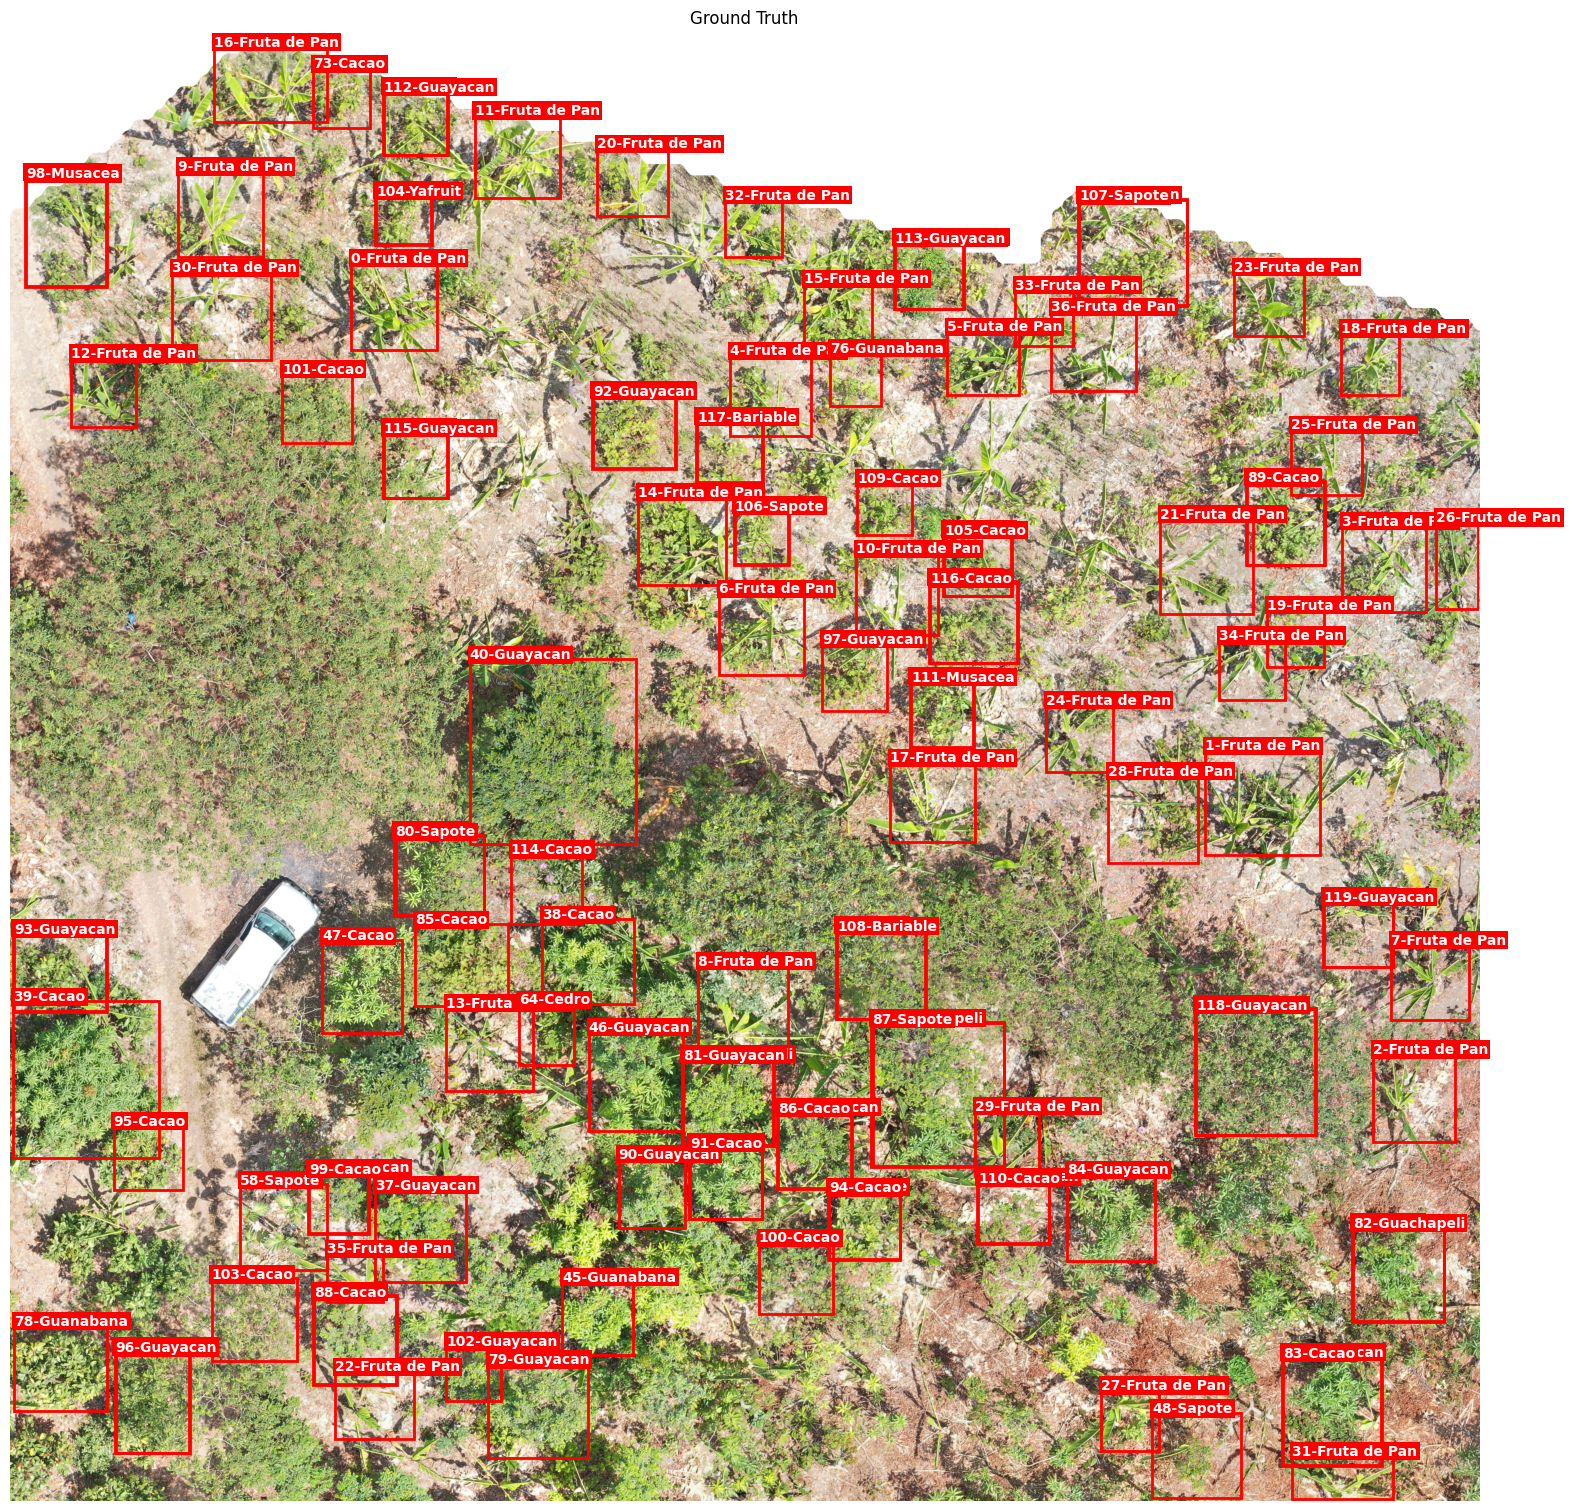

In [50]:
## getting the sample of position 30 in the ds.files list
sample = ds.__getitem__(25)

fig = ds.plot2(sample,
        figsize=(20,15))

In [51]:
plt.close('all')

## 4. DataModule — `ReforesTreeDataModule`

PyTorch Lightning's `DataModule` separates data handling from model logic. This class manages three responsibilities:

**`prepare_data()`** — called once per run (even in multi-GPU setups on a single node), confirms the dataset is on disk.

**`setup(stage)`** — called before each stage (`fit`, `test`, `predict`). Loads the full dataset, then splits it into train/val/test subsets using a seeded `torch.Generator` for reproducibility.

**`collate_fn`** — the most important method for this task. Because each tile has a *variable number of trees* `N`, the default PyTorch collator cannot batch samples into a single tensor. The custom `collate_fn`:
- Adds a batch dimension to the image: `[C, H, W] → [1, C, H, W]`
- Casts bounding boxes to `float32` — **required** by `roi_align`, which uses bilinear interpolation
- Keeps AGB as a per-tree vector `agb_individual` so the training step can compute a filtered sum over only the trees whose patches were processed in that forward pass

> **Why `batch_size=1`?** A single 4000×4000 float32 RGB tile is ~180 MB. One tile already saturates most GPU VRAM. The effective batch size is increased to 4 by setting `accumulate_grad_batches=4` in the Trainer — gradients are accumulated over 4 images before an optimizer step, without requiring 4× the memory.

In [52]:
class ReforesTreeDataModule(LightningModule):
    def __init__(
        self,
        root: str = 'data',
        img_dir: str = 'tiles',
        metadata_path: str = "mapping/final_dataset.csv",
        batch_size: int = 1,  
        num_workers: int = 2,
        train_val_test_split: tuple[float, float, float] = (0.7, 0.15, 0.15),
        transforms: Optional[Callable[[dict[str, Tensor]], dict[str, Tensor]]] = None,
        download: bool = False,
        checksum: bool = False,
        seed: int = 42,
    ):
        super().__init__()
        self.save_hyperparameters()
        self.root = root
        self.img_dir = img_dir
        self.metadata_path = metadata_path
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.train_val_test_split = train_val_test_split
        self.transforms = transforms
        self.download = download
        self.checksum = checksum
        self.seed = seed
        
        # Will be set in setup()
        self.train_dataset = None
        self.val_dataset = None
        self.test_dataset = None
        self.predict_dataset = None

    def prepare_data(self):
        """"""
        ## dataset is already downloaded
        AGB_Reforest(
            root=self.root,
            img_dir=self.img_dir,
            metadata_path=self.metadata_path,
            transforms=None,
            download=False,
            checksum=False,
        )

    def setup(self, stage: Optional[str] = None):
        """Set up train/val/test datasets."""
        
        # Load full dataset
        full_dataset = AGB_Reforest(
            root=self.root,
            img_dir=self.img_dir,
            metadata_path=self.metadata_path,
            transforms=self.transforms,
        )
        
        # Calculate split sizes
        total_size = len(full_dataset)
        train_size = int(self.train_val_test_split[0] * total_size)
        val_size = int(self.train_val_test_split[1] * total_size)
        test_size = total_size - train_size - val_size
        
        # Split dataset
        generator = torch.Generator().manual_seed(self.seed)
        train_dataset, val_dataset, test_dataset = random_split(
            full_dataset, 
            [train_size, val_size, test_size],
            generator=generator
        )
        
        # Assign splits based on stage
        if stage == "fit" or stage is None:
            self.train_dataset = train_dataset
            self.val_dataset = val_dataset
            
        if stage == "test" or stage is None:
            self.test_dataset = test_dataset
            
        if stage == "predict" or stage is None:
            self.predict_dataset = test_dataset  

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            collate_fn=self.collate_fn,
            pin_memory=True,
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            collate_fn=self.collate_fn,
            pin_memory=True,
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            collate_fn=self.collate_fn,
            pin_memory=True,
        )

    def predict_dataloader(self):
        return DataLoader(
            self.predict_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            collate_fn=self.collate_fn,
            pin_memory=True,
        )

    @staticmethod
    def collate_fn(batch):
        # Since batch_size=1, batch is a list with 1 dictionary element
        sample = batch[0]

        ## ensure agb_indid is float32
        agbb = torch.as_tensor(sample['agb'], dtype=torch.float32)
        
        # Ensure total_agb is a 1D tensor [1] instead of a scalar []
        total_agb = torch.as_tensor(sample['agb_total'], dtype=torch.float32).view(1)
        
        # Ensure bboxes are float32 (required for RoI Align)
        bboxes = torch.as_tensor(sample['bbox_xyxy'], dtype=torch.float32)

        return {
            'image': sample['image'].unsqueeze(0),  # [C, H, W] -> [1, C, H, W]
            'bboxes': bboxes,                       # [N_boxes, 4]
            'total_agb': total_agb,                 # [1]
            # Keep other metadata if needed for logging/debugging
            'labels': sample.get('label'),
            'agb_individual': agbb,
            'label_name': sample.get('label_name'),
        }

## 5. Model Architecture

This section builds the full picture: from dataset label quality, through the feature extraction strategy, to the complete forward pass.

### Dataset Context and Label Noise

Field measurements were collected during on-site campaigns: researchers identified each tree, measured DBH and height, and recorded GPS coordinates. These measurements feed allometric equations (e.g., for cacao: `AGB = a × DBH^b`) that convert physical measurements into biomass in kilograms.

The label-to-image matching is inherently imperfect:
- Consumer GPS devices in forest canopy can be off by several metres
- Not every visible crown in a tile has a corresponding field measurement
- Some trees span tile boundaries or are partially occluded

This means AGB targets are **best-effort estimates**, not ground truth. The model must learn robust visual features despite this noise — which is precisely why the **global aggregation loss** (comparing tile-level sums rather than per-tree pairs) is a sensible training strategy: summing over many trees cancels out individual noise.

### Understanding Feature Maps — Visual Embeddings

Before training the full pipeline, it is instructive to visualize what ResNet-18 "sees" at each stage of its computation.

A **feature map** at layer $l$ is a tensor of shape `[C_l, H_l, W_l]` where each of the `C_l` channels activates for a different learned visual pattern. As depth increases, patterns become more semantic:

| Stage | Output shape (from 1000×1000 patch) | Detects |
|---|---|---|
| Layer 1 | `[64, 250, 250]` | Edges, color gradients |
| Layer 2 | `[128, 125, 125]` | Textures, leaf surface patterns |
| Layer 3 | `[256, 63, 63]` | Crown boundary segments |
| Layer 4 | `[256, 32, 32]` | Object-level structures |
| Layer 5 | `[512, 31, 31]` | Semantic crown representations |

**We use the Layer 5 output (512 channels)** as the feature representation for each patch. These are often called *visual embeddings* — a compact, learned encoding of what each spatial location in the image "means" to the network.

The plot below shows the **mean activation across channels** for each layer on a real tile, giving an intuitive sense of how spatial information is progressively compressed and semantically enriched through the network.

In [ ]:
## create a model from a pre-trained weights of a resnet18.

model = timm.create_model('resnet18.a1_in1k',
                      pretrained=True,
                      features_only=True,
                      global_pool = ''
                      )
## get the sample of our dataset 
sample = ds.__getitem__(30)
print(f"tensor org shape:{sample['image'].shape}")

## get the  feature map
fc = model(sample['image'].unsqueeze(dim=0))

# Move all feature maps to CPU and delete GPU references
fc = [ob.detach().cpu() for ob in fc]
torch.cuda.empty_cache()

for ob in fc:
  print(ob.shape)

def plot_feature_maps(features, original_img):
  """
  Plot feature maps from a model
      ARgs:
      features: List[tensors]. Feature Extraction of  backbone
      original_img: tensor. Original tensor representing the image.
  """
  num_cols = 3
  num_rows = math.ceil((len(features)+1) / num_cols)
  fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 10))
  axes = np.array(axes).flatten()

  # Plot original image
  axes[0].imshow(original_img.permute((1, 2, 0)).byte().numpy())
  axes[0].axis('off')

  # Process and plot each feature map one by one
  for i, fmap in enumerate(features):
      mean_map = torch.mean(fmap, dim=1).squeeze().detach().cpu().numpy()
      axes[i+1].imshow(mean_map, cmap='viridis')
      axes[i+1].set_title(f"Layer {i+1}\n{fmap.shape}")
      axes[i+1].axis('off')
      # Optionally, clear memory after each plot
      del mean_map
  plt.show()

plot_feature_maps(fc, sample['image'])

### Architecture: Sparse Feature Regression

The central design challenge is running deep learning on **4000×4000 pixel drone images** without exhausting GPU memory, while retaining spatially precise features for individual tree crowns.

Three naive solutions and why they fail here:
- **Resize to 224×224**: Standard ImageNet input size. Loses all spatial resolution — trees become sub-pixel blobs.
- **Uniform tiling**: Slice into 16 × 250×250 patches, run all through the backbone. Most patches contain only soil or empty canopy — wasteful and risks OOM with a large batch.
- **Full-image pass**: 4000×4000 float32 through ResNet-18 requires ~12 GB VRAM — exceeds most single GPU budgets.

**The solution: Sparse Feature Extraction with a Moving Window**

Only the **1000×1000 patches that contain at least one labeled bounding box** are forwarded through the backbone. The resulting feature maps are assembled into a full-image-size canvas (zeros everywhere else), and RoI Align operates on this sparse canvas.

**Global Aggregation Loss**

Rather than minimizing per-tree MSE, the training objective is:

$$\mathcal{L} = \text{MSE}\!\left(\sum_{i \in \text{valid}} \hat{y}_i,\;\sum_{i \in \text{valid}} y_i\right)$$

The sum runs only over trees in processed patches. This is robust to per-tree label noise and reflects the ecologically relevant metric — total biomass of a surveyed area.

![image_architecture](https://raw.githubusercontent.com/emanuel-gf/ReforesTree/first/img_architecture.png)

The architecture diagram above summarizes the full pipeline. Here is a quick-reference map of each component to the corresponding class/method in the code:

| Component | Code location | Shape transformation |
|---|---|---|
| Input tile | `AGB_Reforest.__getitem__` | `[3, 4000, 4000]` |
| Patch selection | `_get_features_for_bboxes` | identify (i,j) tuples |
| ResNet-18 backbone | `timm.create_model('resnet18.a1_in1k')` | `[3, 1000, 1000] → [512, 31, 31]` |
| Feature canvas assembly | `_get_features_for_bboxes` | `[512, 125, 125]` (sparse) |
| RoI Align | `torchvision.ops.roi_align` | `[N, 512, 31, 31] → [N, 512, 7, 7]` |
| MLP head | `self.regressor` | `[N, 25088] → [N, 1]` |
| Global aggregation | `torch.sum` | `[N, 1] → [1]` |
| Loss | `nn.MSELoss` | scalar |

### Step-by-Step Forward Pass

**Step 1 — Selective Backbone Pass** (`_get_features_for_bboxes`)  
For each bounding box in the tile, the method computes which 1000×1000 patches it overlaps. Only those patches are forwarded through the frozen ResNet-18 backbone. Feature maps are written into a zero-initialized canvas of shape `[1, 512, H/32, W/32]`.

**Step 2 — Spatial Reduction (32×)**  
ResNet-18 applies a cumulative downsampling factor of **32×**. A 1000×1000 patch becomes a 31×31 feature map with 512 channels. Each feature vector covers a ~32×32 pixel receptive field — roughly the scale of a small tree crown.

**Step 3 — RoI Align** (`torchvision.ops.roi_align`)  
Each bounding box is mapped from pixel coordinates to feature-map coordinates via `spatial_scale = 1/32`. RoI Align then extracts a **7×7 feature grid** for each box using bilinear interpolation, normalising all crowns to the same feature size regardless of their physical dimensions in the image.

**Step 4 — MLP Regression Head**  
The 7×7×512 = 25,088-dimensional feature vector per tree is passed through:
```
Linear(25088 → 256) → ReLU → Dropout(0.2) → Linear(256 → 1)
```
The output is one scalar — the predicted z-score normalized AGB for that tree.

**Step 5 — Global Aggregation**  
`torch.sum` collapses all per-tree predictions into a single tile-level AGB estimate. This scalar is compared against the sum of ground-truth z-score normalized AGB values for the same trees to compute the MSE loss.

## 6. Model — `AGBTrainableRegressor`

The full model is a `LightningModule` that combines the frozen backbone, sparse feature extraction logic, RoI Align, and the trainable MLP head.

Key implementation decisions:

| Decision | Rationale |
|---|---|
| **Frozen backbone** (`freeze_backbone=True`) | With ~100 tiles and ~4600 trees, fine-tuning ResNet-18 would overfit severely. Pretrained ImageNet features are already rich enough for crown texture and color discrimination. Only the MLP head is trained. |
| **`@torch.inference_mode()`** on backbone methods | No gradient graph is built during the backbone forward pass — halving VRAM usage and accelerating feature extraction. Gradients flow only through the MLP head. |
| **`valid_indices` tracking** | Because only some patches are processed per forward pass, we must track which trees were included so the loss is computed on a matching subset of ground-truth values. |
| **Clipped bboxes** before RoI Align | Bounding boxes from the annotation CSV can extend slightly beyond tile boundaries due to GPS rounding. Clipping to `[0, img_w] × [0, img_h]` prevents RoI Align from sampling out-of-bounds memory. |

In [75]:


class AGBTrainableRegressor(LightningModule):
    def __init__(
        self,
        output_dim: int = 1,
        freeze_backbone: bool = True,
        learning_rate: float = 1e-4,
    ):
        super().__init__()
        self.save_hyperparameters()

        # Backbone ResNet18 - Lean & Fast
        self.backbone = timm.create_model(
            'resnet18.a1_in1k',
            pretrained=True,
            num_classes=0,
            global_pool=''
        )

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
            self.backbone.eval()

        self.feature_dim = 512
        self.reduction = 32 ## reduction of ResNet18
        self.roi_size = 7

        # input is pooled tree features, output is biomass (scalar)
        self.regressor = nn.Sequential(
            nn.Linear(self.feature_dim * self.roi_size * self.roi_size, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, output_dim)
        )

        self.criterion = nn.MSELoss()
        self.learning_rate = learning_rate

    @torch.inference_mode()
    def _get_features_tiled(self, image, patch_size=1000):
        """Internal helper to extract features without tracking gradients."""
        b, c, h, w = image.shape
        out_h, out_w = h // self.reduction, w // self.reduction

        # Allocate canvas on GPU
        canvas = torch.zeros((b, self.feature_dim, out_h, out_w),
                             dtype=torch.float32, device=self.device)

        for i in range(0, h, patch_size):
            for j in range(0, w, patch_size):
                patch = image[:, :, i:i+patch_size, j:j+patch_size].to(self.device)
                feat = self.backbone(patch)

                si, sj = i // self.reduction, j // self.reduction
                ei, ej = si + feat.shape[2], sj + feat.shape[3]
                canvas[:, :, si:ei, sj:ej] = feat
                del patch, feat

        return canvas

    @torch.inference_mode()
    def _get_features_for_bboxes(self, image, bboxes, patch_size=1000):
        """
        Extract features only for patches containing bounding boxes.
        
        Returns:
            canvas: Feature map for the entire image
            patches_needed: Set of (i, j) tuples indicating which patches were processed
        """
        b, c, h, w = image.shape
        out_h, out_w = h // self.reduction, w // self.reduction
        
        # Handle empty bboxes case
        if bboxes[0].shape[0] == 0:
            return torch.zeros((b, self.feature_dim, out_h, out_w),
                              dtype=torch.float32, device=self.device), set()
        
        # Determine which patches contain bboxes
        patches_needed = set()
        for bbox in bboxes[0]:
            x1, y1, x2, y2 = bbox.int()
            # Find which patches overlap with this bbox
            patch_x_start = max(0, (x1.item() // patch_size) * patch_size)
            patch_x_end = min(w, ((x2.item() // patch_size) + 1) * patch_size)
            patch_y_start = max(0, (y1.item() // patch_size) * patch_size)
            patch_y_end = min(h, ((y2.item() // patch_size) + 1) * patch_size)
            
            for i in range(patch_y_start, patch_y_end, patch_size):
                for j in range(patch_x_start, patch_x_end, patch_size):
                    patches_needed.add((i, j))
        
        # Allocate canvas
        canvas = torch.zeros((b, self.feature_dim, out_h, out_w),
                             dtype=torch.float32, device=self.device)
        
        # Process only needed patches
        for i, j in patches_needed:
            # Extract patch with proper boundary handling
            patch_h = min(patch_size, h - i)
            patch_w = min(patch_size, w - j)
            patch = image[:, :, i:i+patch_h, j:j+patch_w].to(self.device)
            feat = self.backbone(patch)
            
            # Place features in canvas
            si, sj = i // self.reduction, j // self.reduction
            ei, ej = si + feat.shape[2], sj + feat.shape[3]
            canvas[:, :, si:ei, sj:ej] = feat
            del patch, feat
        
        return canvas, patches_needed

    def _filter_bboxes_in_patches(self, bboxes, patches_needed, patch_size=1000,
                                 img_width=None, img_height=None
                                 ):
        """
        Filter bboxes to only include those within processed patches.
        
        Returns:
            valid_bboxes: List of bboxes that are in processed patches
            valid_indices: List of original indices of valid bboxes
        """
        valid_bboxes = []
        valid_indices = []
        
        for idx, bbox in enumerate(bboxes[0]):
            x1, y1, x2, y2 = bbox.int()
            
            # Check if this bbox overlaps with any processed patch
            bbox_in_processed_patch = False
            patch_x_start = max(0, (x1.item() // patch_size) * patch_size)
            patch_x_end = min(img_width, ((x2.item() // patch_size) + 1) * patch_size) 
            patch_y_start = max(0, (y1.item() // patch_size) * patch_size)
            patch_y_end = min(img_height, ((y2.item() // patch_size) + 1) * patch_size) 
            
            for i in range(patch_y_start, patch_y_end, patch_size):
                for j in range(patch_x_start, patch_x_end, patch_size):
                    if (i, j) in patches_needed:
                        bbox_in_processed_patch = True
                        break
                if bbox_in_processed_patch:
                    break
            
            if bbox_in_processed_patch:
                valid_bboxes.append(bbox)
                valid_indices.append(idx)
        
        return valid_bboxes, valid_indices


    def forward(self, image, bboxes, individual_agbs_target=None):
        """
        Args:
            image: Input image [1, 3, H, W]
            bboxes: List of bboxes [N, 4]
            individual_agbs_target: Optional [N, 1] tensor of individual AGB values for each bbox
        
        Returns:
            total_agb: Summed biomass for processed patches (trainable)
            individual_agbs: Biomass per tree in processed patches (for analysis)
            valid_indices: Indices of bboxes that were processed
        """
        # Handle case where no bboxes exist in the patch
        if bboxes[0].shape[0] == 0:
            return (torch.tensor([0.0], device=self.device, requires_grad=True), 
                    torch.tensor([], device=self.device),
                    [])
        
        # 1. Feature Extraction - Only for patches with bboxes
        feature_map, patches_needed = self._get_features_for_bboxes(image, bboxes, patch_size=1000)
        
        # 2. Filter bboxes to only those in processed patches
        valid_bboxes_list, valid_indices = self._filter_bboxes_in_patches(
            bboxes, patches_needed, patch_size=1000,
            img_width=image.shape[3], img_height=image.shape[2]  # ADD THESE
        )
        
        if len(valid_bboxes_list) == 0:
            return (torch.tensor([0.0], device=self.device, requires_grad=True), 
                    torch.tensor([], device=self.device),
                    [])
        
        # 3. Clip bboxes to image boundaries
        img_h, img_w = image.shape[2], image.shape[3]
        clipped_bboxes = []
        
        for bbox in valid_bboxes_list:
            x1, y1, x2, y2 = bbox
            clipped_bbox = torch.tensor([
                max(0.0, x1.item()),
                max(0.0, y1.item()),
                min(float(img_w), x2.item()),
                min(float(img_h), y2.item())
            ], device=self.device, dtype=torch.float32)
            clipped_bboxes.append(clipped_bbox)
        
        clipped_bboxes = torch.stack(clipped_bboxes)
        
        # 4. RoI Align 
        roi_feats = roi_align(
            feature_map,
            [clipped_bboxes],
            output_size=(self.roi_size, self.roi_size),
            spatial_scale=1.0 / self.reduction
        )

        # 5. Regression Head
        roi_feats = roi_feats.flatten(1)
        individual_agbs = self.regressor(roi_feats)  # [N_valid_trees, 1]

        # 6. Global Aggregation
        total_agb = torch.sum(individual_agbs).view(1)  # Force shape [1]

        return total_agb, individual_agbs, valid_indices


    def training_step(self, batch, batch_idx):
        img = batch['image']  # Shape: [1, 3, H, W]
        bboxes = batch['bboxes']  # tensor [N, 4]
        individual_agbs_target = batch.get('agb_individual', None)  # [N, 1] or [N] - AGB per tree

        #print(f"training_step")
        #print(f"img:{img.shape}, bbox:{bboxes.shape}, indiv_agb_target:{individual_agbs_target.shape if individual_agbs_target is not None else 'None'}")
        #print()

        # Forward pass
        pred_agb, pred_individual_agbs, valid_indices = self(img, [bboxes], individual_agbs_target)

        ## debug
        #print("predagb", len(pred_agb))
        #print(f"valid_indices: {len(valid_indices)}")
        #print(f"vector value of prediction abg (first 5): {pred_individual_agbs[:5].detach().cpu().numpy().tolist()}")
        #print(f"value of target (first 5): {individual_agbs_target[:5].detach().cpu().numpy().tolist()}")
        ##print(f"sum value of predagb: {pred_agb.detach().cpu().item():.4f}") 
        
        # Calculate target AGB for only the processed bboxes
        if individual_agbs_target is not None:
            # Sum only the AGB values for trees in processed patches
            target_agb = torch.sum(individual_agbs_target[valid_indices]).view(1)
            ##print(f" sum target_agb: {target_agb}")
        else:
            ##print(f" SOME ERROR HERE:")
            # Fallback: use total_agb if individual values aren't available
            # NOTE: This will cause a mismatch if not all patches are processed!
            target_agb = batch['total_agb']
            print(f"WARNING: Using total_agb without filtering. This may cause training issues!")
        
        loss = self.criterion(pred_agb, target_agb)
        
        self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True)
        self.log('train_n_trees_processed', len(valid_indices), on_step=True, on_epoch=True)
    
        return loss

    def validation_step(self, batch, batch_idx):
        img = batch['image']  # Shape: [1, 3, H, W]
        bboxes = batch['bboxes']  # tensor [N, 4]
        individual_agbs_target = batch.get('agb_individual', None)  # ← Fixed key name
        
        # Forward pass
        pred_agb, pred_individual_agbs, valid_indices = self(img, [bboxes], individual_agbs_target)
        
        # Calculate target AGB for only the processed bboxes
        if individual_agbs_target is not None:
            target_agb = torch.sum(individual_agbs_target[valid_indices]).view(1)
        else:
            target_agb = batch['total_agb']
            print(f"WARNING: Using total_agb without filtering. This may cause validation issues!")
        
        loss = self.criterion(pred_agb, target_agb)
    
        self.log('val_loss', loss, on_step=True, on_epoch=True, prog_bar=True, logger=True, sync_dist=True)
        self.log('val_n_trees_processed', len(valid_indices), on_step=True, on_epoch=True)
        return loss

    def test_step(self, batch, batch_idx):
        img = batch['image'] # Shape: [1, 3, H, W]
        bboxes = batch['bboxes'] #tensor [N, 4]
        individual_agbs_target = batch.get('agb_individual', None)
    
        # Forward pass
        pred_agb, pred_individual_agbs, valid_indices = self(img, [bboxes], individual_agbs_target)
    
        # Calculate target AGB for only the processed bboxes
        if individual_agbs_target is not None:
            target_agb = torch.sum(individual_agbs_target[valid_indices]).view(1)
        else:
            target_agb = batch['total_agb']
            print(f"WARNING: Using total_agb without filtering. This may cause test issues!")
        
        loss = self.criterion(pred_agb, target_agb)  
    
        self.log('test_loss', loss, on_step=True, on_epoch=True, prog_bar=True, logger=True, sync_dist=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.regressor.parameters(), lr=self.learning_rate)


## 7. Training, Validation & Test

### Hyperparameter Rationale

| Parameter | Value | Rationale |
|---|---|---|
| `max_epochs` | 18 | Empirically sufficient for the MLP to converge with a frozen backbone. More epochs risk overfitting on ~70 training tiles. |
| `batch_size` | 1 | Memory constraint — one 4000×4000 float32 RGB tile is ~180 MB. |
| `accumulate_grad_batches` | 4 | Effective batch size = 4, without extra VRAM. |
| `learning_rate` | 1e-4 | Standard Adam starting rate for a small regression head. |
| `precision` | `16-mixed` | Automatic Mixed Precision: forward pass and loss in float16, optimizer step in float32. ~2× throughput on modern GPUs. |
| `accelerator` | `gpu` | Required for RoI Align on large feature tensors in reasonable time. |

### Experiment Tracking with Weights & Biases

WandB logs every `train_loss` and `val_loss` step, plus `n_trees_processed` per step. Monitoring the tree count during training is useful — it confirms the sparse extraction is consistently hitting a representative sample of the dataset rather than always landing on the same dense/sparse patches.

The Kaggle Secrets vault injects the WandB API key without hardcoding credentials in the notebook. On Google Colab, replace the secrets block with `wandb.login(key="YOUR_KEY")`.

`ModelCheckpoint` monitors `val_loss_epoch` and saves the single best checkpoint, which is then reloaded for the final test evaluation.

In [ ]:
## integrate with weight and bias 
!pip install wandb

In [54]:
from kaggle_secrets import UserSecretsClient
import wandb

# Get the secret from Kaggle
user_secrets = UserSecretsClient()
wandb_key = user_secrets.get_secret("wandb")

#  Set the environment variable so WandB doesn't try to "write" a file
os.environ["WANDB_API_KEY"] = wandb_key

#login now works without needing to write to the filesystem
wandb.login()


wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


True

In [55]:
from datetime import datetime
## name of the run

## Finish any existing wandb run before starting a new one
if wandb.run is not None:
    wandb.finish()

## Create unique run name with timestamp
timestamp = datetime.now().strftime("%d_%H%M")
name_of_run = f"agb4_obia_1000x_10epoch_acumgrad_{timestamp}"

wandb_logger = WandbLogger(log_model="all",
                          project="Above_Ground_Biomass",
                          name = name_of_run,
                            reinit=True  # Force new run
                          )

## seed
seed_everything(42, workers=True)


# Initialize datamodule
datamodule = ReforesTreeDataModule(
    root = "/kaggle/input/reforestree-dataset",
    metadata_path = "mapping/final_dataset.csv",
    batch_size=1,
    num_workers=2,
    train_val_test_split=(0.7, 0.15, 0.15),
    download=True,
)

# Initialize model
model = AGBTrainableRegressor(
    output_dim=1,
    freeze_backbone=True,
    learning_rate=1e-4,
)

checkpoint_callback = ModelCheckpoint(
    monitor='val_loss_epoch',
    mode='min',
    save_top_k=1,
    dirpath='checkpoints/',
    filename='agb-regressor-{epoch:02d}-{val_loss:.2f}'
)

# Train
trainer = Trainer(
    logger = wandb_logger,
    max_epochs=18,
    accumulate_grad_batches=4,
    accelerator='gpu',
    devices=1,
    precision='16-mixed',
    callbacks=[checkpoint_callback],
    log_every_n_steps=1,
    check_val_every_n_epoch=1,
    enable_progress_bar=True,
    enable_model_summary=True,
)

## train 
trainer.fit(model,
            datamodule = datamodule)

## validate
trainer.validate(model=model,
                 datamodule=datamodule)

## test after all run
# automatically loads the best weights 
trainer.test(model,
              datamodule = datamodule,
             weights_only = True
             )


epoch,▁▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇████
train_loss_epoch,█▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss_step,▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_n_trees_processed_epoch,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_n_trees_processed_step,█▂▂▄▁▂▅▂▇▁▆▃▂▄▂▅▂▅▄▄▄▃▃▂▂▃▄▄▁▄▁▄▄▃▂▃▂▂▁▅
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▆▆▆▇█▁
val_loss_epoch,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss_step,▂▁▆▁▁▇▃▁▅▁█▃▁▂▁▄▇▂▂▅▁▁▁▃▁▂▁▁▂▁▂▂▁▁▄▃▄▄▂▁
val_n_trees_processed_epoch,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_n_trees_processed_step,▁▄█▅▅▁█▅▅▄▅▅▅▇▅▅▃▁▁▅▂▃▁▄▇█▄▅▅▄▅▇▅█▅▁▁▅█▅
epoch,18


Seed set to 42
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ backbone  │ ResNet     │ 11.2 M │ eval  │     0 │
│ 1 │ regressor │ Sequential │  6.4 M │ train │     0 │
│ 2 │ criterion │ MSELoss    │      0 │ train │     0 │
└───┴───────────┴────────────┴────────┴───────┴───────┘

Trainable params: 6.4 M                                                                                            
Non-trainable params: 11.2 M                                                                                       
Total params: 17.6 M                                                                                               
Total estimated model params size (MB): 70                                                                         
Modules in train mode: 6                                                                                           
Modules in eval mode: 94                                                                                           
Total FLOPs: 0

...

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃       Validate metric       ┃        DataLoader 0         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       val_loss_epoch        │      7.001593112945557      │
│ val_n_trees_processed_epoch │     35.733333587646484      │
└─────────────────────────────┴─────────────────────────────┘

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Output()

AttributeError: 'ReforesTreeDataModule' object has no attribute 'on_exception'

### Training Curves

The loss plotted here is **MSE on z-score normalised AGB**. To interpret the scale:

AGB was normalized as $z = (y - \mu) / \sigma$ where the training set statistics are $\mu \approx 13.04$ kg and $\sigma \approx 54.50$ kg. An MSE of $L$ in normalized space corresponds to an RMSE of $\sqrt{L} \times 54.5$ kg in raw AGB:

| Normalized MSE | RMSE in kg |
|---|---|
| 1.0 | ~54.5 kg |
| 4.0 | ~109 kg |
| 9.0 | ~163 kg |

What to look for:
- **Steady decrease** in train loss over the first ~10 epochs as the MLP head learns to associate crown features with biomass ranges.
- **Validation loss tracking train loss** — significant divergence indicates overfitting to the training sites.
- A **plateau after epoch 10–12** is expected given the frozen backbone and small dataset size. The model is learning to reweight the fixed ResNet features, not learning new representations.

Training and validation history is pulled directly from the WandB run API, grouped by epoch, and forward-filled to handle steps where only one of the two losses was logged.

In [58]:
# Download run history from WandB
api = wandb.Api()
run = api.run(f"emanuelgoulartf-paris-lodron-universit-t-salzburg/Above_Ground_Biomass/0mdfv19g")


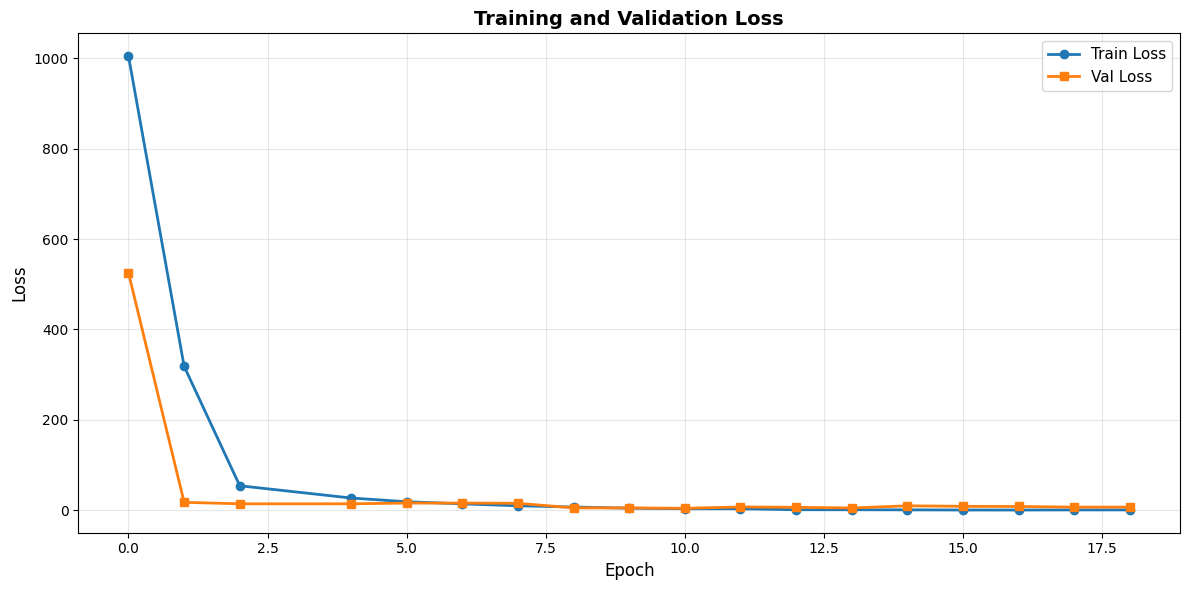

In [59]:

history = run.history()

# Group by epoch and get mean values
epoch_data = history.groupby('epoch').agg({
    'train_loss_epoch': 'mean',
    'val_loss_epoch': 'mean'
}).reset_index()

# Remove rows where BOTH train and val are NaN (shouldn't happen but just in case)
epoch_data = epoch_data[~(epoch_data['train_loss_epoch'].isna() & epoch_data['val_loss_epoch'].isna())]

# fill NaNs if an entire epoch was missing a value
epoch_data[train_loss_col] = epoch_data[train_loss_col].ffill()
epoch_data[val_loss_col] = epoch_data[val_loss_col].ffill()
# Plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(epoch_data['epoch'], epoch_data[train_loss_col], 
        label='Train Loss',
        marker='o',
        linestyle='-',
        linewidth=2,
        markersize=6
       )
ax.plot(epoch_data['epoch'], epoch_data[val_loss_col], 
        label='Val Loss', 
        marker='s',
        linestyle='-',
        linewidth=2,
        markersize=6
       )

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Test Evaluation

`Trainer.test()` runs inference over the held-out test split (15% of tiles, ~15 images) using the best checkpoint selected during training, and reports the epoch-averaged test MSE.

**Interpreting the results**:

The best checkpoint achieved `val_loss ≈ 4.39` (normalised MSE), corresponding to an RMSE of ~109 kg per tile-level sum. The test loss of ~120.6 reflects the genuine difficulty of this task:

- The dataset is small (~100 tiles total) and may not represent full site-to-site variability in the test split
- AGB in agroforestry systems has high spatial variability — tile-level biomass sums differ dramatically between sites and species compositions
- The model was trained with a global sum loss, meaning individual tree predictions carry inherent uncertainty

Despite the raw loss numbers, the qualitative per-tree predictions in the next section reveal that the model has learned meaningful biomass patterns. The checkpoint path printed below is saved to Kaggle's `/kaggle/working/` directory.

In [76]:
# Get the best model path
best_checkpoint_path = checkpoint_callback.best_model_path
print(f"Best checkpoint: {best_checkpoint_path}")

# Load and test
model = AGBTrainableRegressor.load_from_checkpoint(best_checkpoint_path)
trainer.test(model, datamodule=datamodule)


Best checkpoint: /kaggle/working/checkpoints/agb-regressor-epoch=10-val_loss=4.39-v2.ckpt


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      test_loss_epoch      │    120.63174438476562     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss_epoch': 120.63174438476562}]

### Per-Tree Biomass Predictions

`plot_biomass_predictions` compares **ground truth AGB** (left, green boxes) against **model predictions** (right, red boxes) for the same set of processed trees. Both the individual per-tree values and the tile-level sum are shown after **de-normalisation** back to kilograms.

De-normalisation reverses the z-score transform: $y_{\text{kg}} = z \times \sigma + \mu$ where $\sigma = 54.50$ and $\mu = 13.04$.

What to observe:
- **Sum AGB in the titles**: The predicted sum vs. ground truth sum gives a direct read on calibration. If they are in the same order of magnitude, the global aggregation loss has worked.
- **Per-tree values**: Individual predictions will vary. Some trees will be over- or under-estimated — expected given indirect supervision and label noise.
- **Species-linked patterns**: Larger crowns (timber, fruit trees) should tend toward higher predicted AGB. If the model has learned meaningful features, this ordering should be visible.
- **`valid_indices`**: Only trees whose bounding boxes overlapped a computed 1000×1000 patch are shown. Trees near tile edges with no neighboring annotations may be excluded.

In [96]:
import matplotlib.patches as patches
from matplotlib.figure import Figure

def plot_biomass_predictions(
    sample: dict,
    pred_total_agb: float,
    pred_individual_agbs: torch.Tensor,
    valid_indices: list,
    figsize: tuple[int, int] = None,
    show_titles: bool = True,
    std_norm = 54.50 ,
    mean_norm = 13.04 ,
    color: str = 'red',
) -> Figure:
    """
    Plots GT vs Predicted biomass.
    """
    # 1. Prepare Image
    # Convert from [C, H, W] to [H, W, C] and handle normalization if necessary
    img_tensor = sample['image']
    if img_tensor.dtype == torch.float:
        # If float, assume 0-1 range; if byte, use as is
        image = img_tensor.permute(1, 2, 0).cpu().byte().numpy()
    else:
        image = img_tensor.permute(1, 2, 0).cpu().byte().numpy()

    # 2. Extract Data
    gt_bboxes = sample['bbox_xyxy']
    gt_individuals = sample.get('agb', None)
    
    # Filter GT for what was actually processed by the model
    valid_gt_bboxes = gt_bboxes[valid_indices]
    valid_gt_agbs = gt_individuals[valid_indices] if gt_individuals is not None else None
    
    gt_sum = valid_gt_agbs.sum().item() if valid_gt_agbs is not None else 0.0

    #  De-normalize the Scalar Sums
    gt_sum = (gt_sum * std_norm) + mean_norm
    pred_total_agb = (pred_total_agb * std_norm) + mean_norm
    
    # De-normalize the Individual Vectors
    if valid_gt_agbs is not None:
        valid_gt_agbs = (valid_gt_agbs * std_norm) + mean_norm
    
    if pred_individual_agbs is not None:
        pred_individual_agbs = (pred_individual_agbs * std_norm) + mean_norm

    #  Setup Plot
    fig, axs = plt.subplots(1, 2, figsize=figsize or (18, 9), constrained_layout=True)
    
    # Define labels for the title
    title_gt = f"Ground Truth\nSum AGB: {gt_sum:.2f}"
    title_pred = f"Predictions\nSum AGB: {pred_total_agb:.2f}"

    # Helper function to draw boxes and text
    def draw_data(ax, img, bboxes, biomass_values, title, box_color):
        ax.imshow(img)
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.axis('off')
        
        for i, bbox in enumerate(bboxes):
            x1, y1, x2, y2 = bbox.cpu().numpy()
            val = biomass_values[i].item()
            
            # Draw Rectangle
            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=1.5, edgecolor=box_color, facecolor='none'
            )
            ax.add_patch(rect)
            
            # Draw Biomass Label
            ax.text(
                x1, y1 - 2, f"{val:.2f}",
                color='white', fontsize=8, fontweight='bold',
                bbox=dict(facecolor=box_color, alpha=0.7, edgecolor='none', pad=1)
            )

    # 4. Draw Ground Truth (Left)
    draw_data(axs[0], image, valid_gt_bboxes, valid_gt_agbs, title_gt, 'green')

    # 5. Draw Predictions (Right)
    draw_data(axs[1], image, valid_gt_bboxes, pred_individual_agbs, title_pred, color)

    return fig

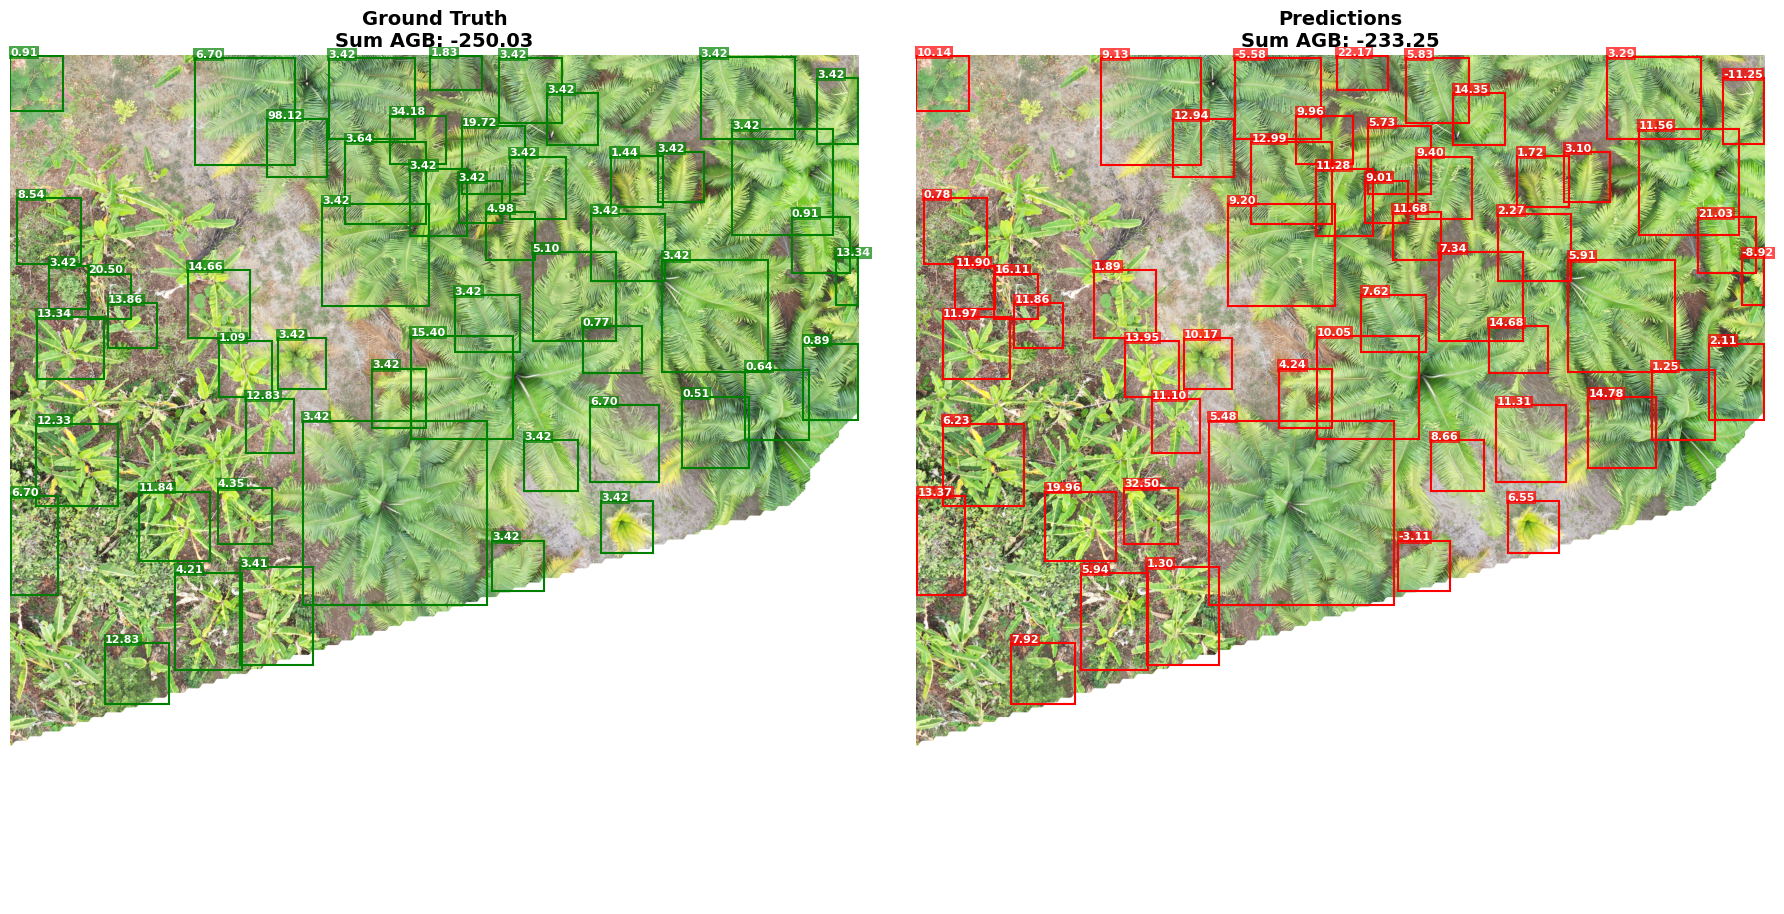

In [97]:
model.eval()
model = model.to('cuda')

with torch.no_grad():
    sample = datamodule.test_dataset[3]  # or any sample
    img = sample['image'].unsqueeze(0).to('cuda')  # Add batch dimension and move to GPU
    bboxes = sample['bbox_xyxy']
    individual_agbs_target = sample.get('agb', None)
    
    # Get predictions
    pred_total_agb, pred_individual_agbs, valid_indices = model(
        img, 
        [bboxes], 
        individual_agbs_target
    )
    
    # Plot
    fig = plot_biomass_predictions(
        sample=sample,
        pred_total_agb=pred_total_agb.item(),
        pred_individual_agbs=pred_individual_agbs,
        valid_indices=valid_indices
    )
    plt.show()

# Next Steps

Are you curious where next step could guide you?

I would encourage to try other approaches of extracting features from different and state-of-art models.

- What if you give a try and implement DinoV3 as a backbone extractor of individual bounding box and use the sum of these bounding box as a regression task? 
- Perhaps estabilishing a multi-regression for each individual bounding box over the feature extracted encoded variables and creating a MLP head to that poursese
- Testing new frontiers of foundation models, specially, high-resolution foundation models.